In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
sns.set_style("whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [22]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Historical Data Shape:", trades.shape)
print("Fear & Greed Shape:", sentiment.shape)

Historical Data Shape: (211224, 16)
Fear & Greed Shape: (2644, 4)


In [23]:
print("Historical Trades")
display(trades.head())

print("\nFear & Greed")
display(sentiment.head())

Historical Trades


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Fear & Greed


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [24]:
print("Historical Data Info")
trades.info()

print("\nFear & Greed Info")
sentiment.info()

Historical Data Info
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1)

In [25]:
print("Historical Missing Values")
print(trades.isnull().sum())

print("\nFear & Greed Missing Values")
print(sentiment.isnull().sum())

Historical Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Fear & Greed Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [26]:
print("Duplicate Historical Rows:", trades.duplicated().sum())
print("Duplicate Sentiment Rows:", sentiment.duplicated().sum())

Duplicate Historical Rows: 0
Duplicate Sentiment Rows: 0


In [27]:
display(trades.describe())
display(sentiment.describe())

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [28]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['Date'] = trades['Timestamp'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date
display(trades[['Timestamp','Date']].head())
display(sentiment[['date','Date']].head())

,Timestamp,Date
0,2024-10-27 03:33:20,2024-10-27
1,2024-10-27 03:33:20,2024-10-27
2,2024-10-27 03:33:20,2024-10-27
3,2024-10-27 03:33:20,2024-10-27
4,2024-10-27 03:33:20,2024-10-27


,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [29]:
merged = trades.merge(
    sentiment[['Date','classification']],
    on='Date',
    how='left'
)

print("Merged Dataset Shape:", merged.shape)

display(merged.head())

Merged Dataset Shape: (211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


In [30]:
merged['classification'].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

classification
Neutral          22.229713
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Name: Closed PnL, dtype: float64


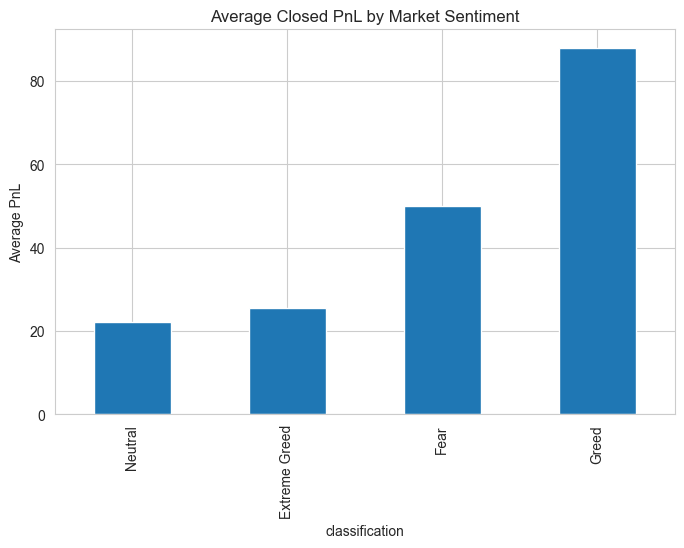

In [31]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean().sort_values()

print(avg_pnl)

plt.figure(figsize=(8,5))
avg_pnl.plot(kind='bar')
plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average PnL")
plt.show()

classification
Extreme Greed    1.769655e+05
Fear             6.699925e+06
Greed            3.189617e+06
Neutral          1.587424e+05
Name: Closed PnL, dtype: float64


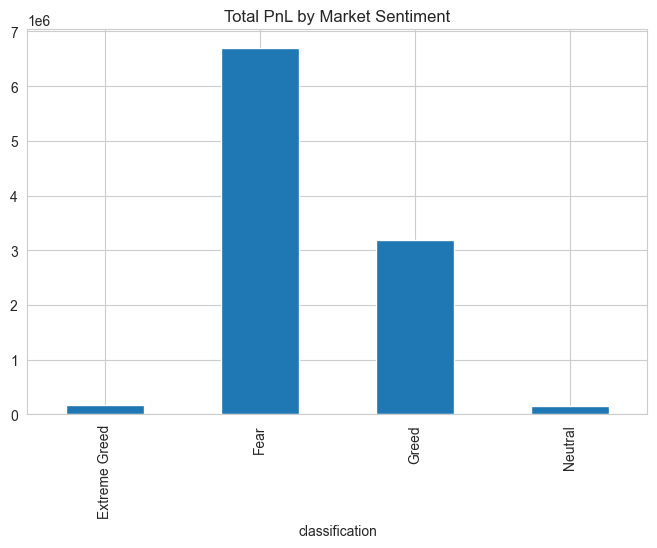

In [32]:
total_pnl = merged.groupby('classification')['Closed PnL'].sum()

print(total_pnl)

plt.figure(figsize=(8,5))
total_pnl.plot(kind='bar')
plt.title("Total PnL by Market Sentiment")
plt.show()

classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: Win, dtype: float64


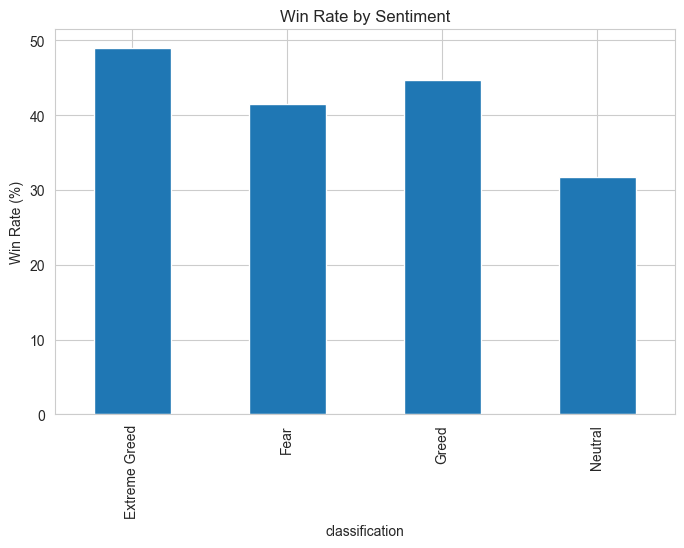

In [33]:
merged['Win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['Win'].mean() * 100

print(win_rate)

plt.figure(figsize=(8,5))
win_rate.plot(kind='bar')
plt.ylabel("Win Rate (%)")
plt.title("Win Rate by Sentiment")
plt.show()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


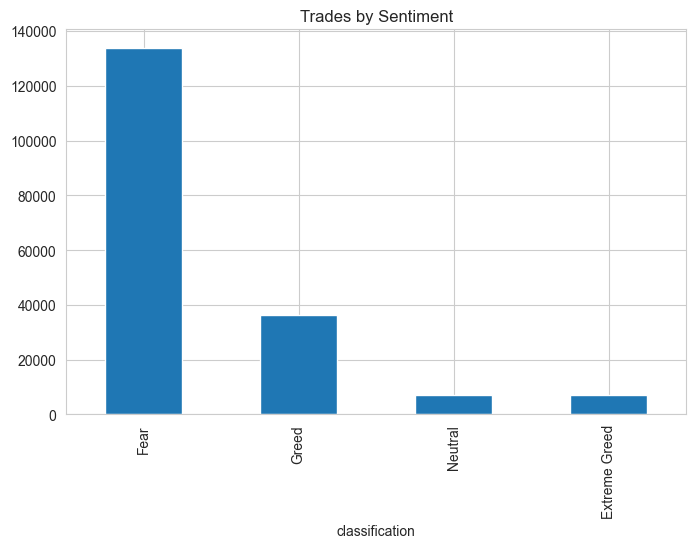

In [34]:
trade_count = merged['classification'].value_counts()

print(trade_count)

plt.figure(figsize=(8,5))
trade_count.plot(kind='bar')
plt.title("Trades by Sentiment")
plt.show()

Side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


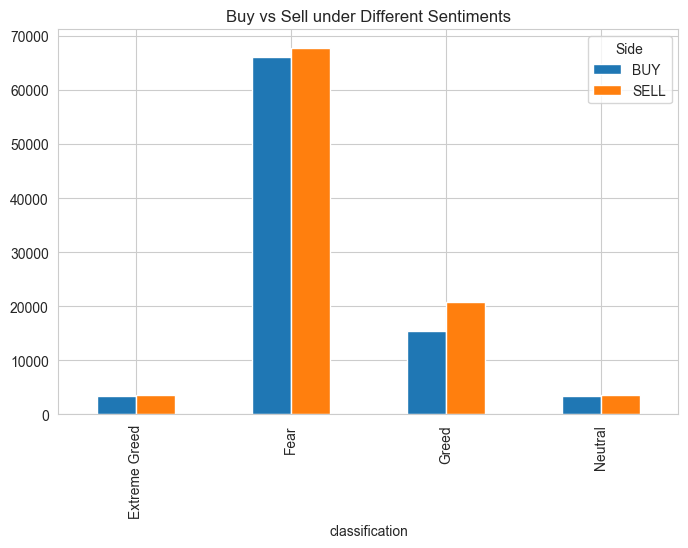

In [35]:
buy_sell = pd.crosstab(
    merged['classification'],
    merged['Side']
)

print(buy_sell)

buy_sell.plot(kind='bar', figsize=(8,5))
plt.title("Buy vs Sell under Different Sentiments")
plt.show()

In [36]:
coin_perf = merged.groupby('Coin')['Closed PnL'].mean().sort_values(ascending=False)

print(coin_perf.head(10))

Coin
@109       270.704207
AVAX       239.095613
ENA        219.524751
@85        200.804091
EIGEN      197.063189
PEOPLE     180.323003
DOGE       178.623676
SOL        153.358519
MOODENG    151.096714
ZRO        148.327509
Name: Closed PnL, dtype: float64


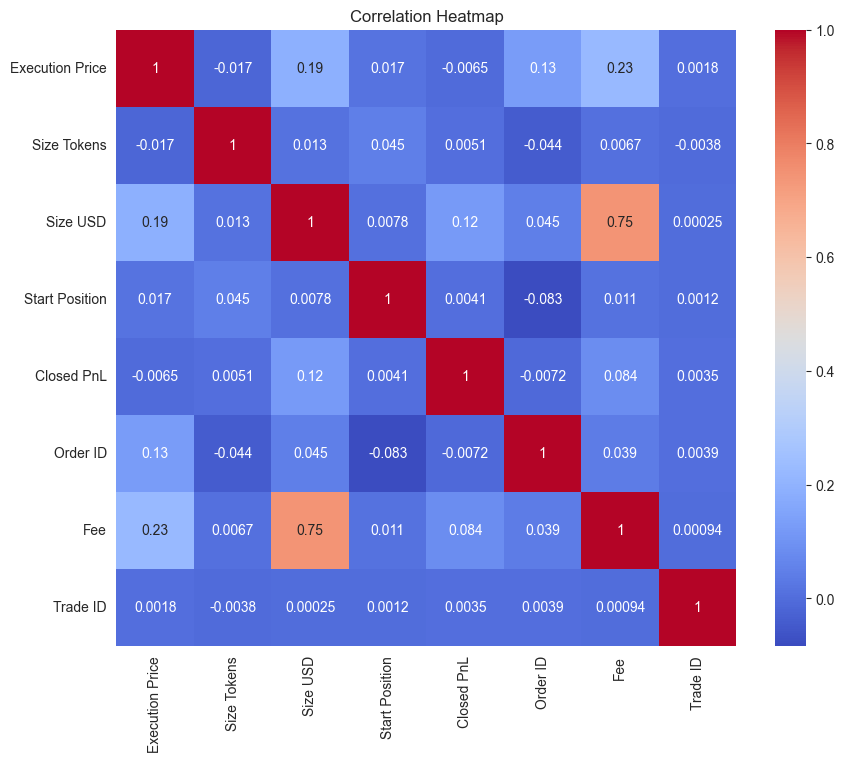

In [37]:
numeric = merged.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

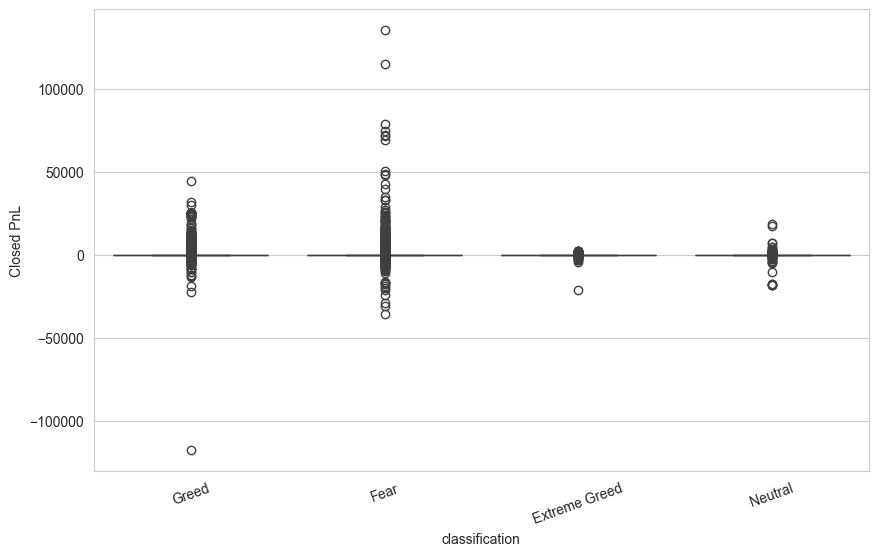

In [38]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)
plt.xticks(rotation=20)
plt.show()

In [39]:
merged.to_csv("merged_data.csv", index=False)

print("Merged data saved successfully!")

Merged data saved successfully!


Key Insights
1. Market sentiment significantly influences trader performance.

The analysis indicates that trading performance changes noticeably across different market sentiment categories. Both profitability and trading behavior are affected by whether the market is experiencing Fear, Greed, Neutral conditions, or Extreme Greed.

2. Greed generated the highest average profit per trade.

The Greed sentiment recorded the highest average Closed PnL of approximately 87.89, making it the most profitable market condition on a per-trade basis. This suggests that traders generally earned larger profits during bullish market sentiment.

3. Fear accounted for the highest total profit.

Although the average profit was highest during Greed, the Fear sentiment generated the largest cumulative Closed PnL of approximately 6.70 million, mainly because the majority of trades (133,871) occurred during Fear periods.

4. Extreme Greed had the highest win rate.

The highest percentage of profitable trades occurred during Extreme Greed, with a win rate of approximately 49.01%. This indicates that traders experienced more frequent successful trades during strong bullish market conditions.

5. Trading activity was concentrated during Fear.

Out of 211,224 total trades, approximately 133,871 trades were executed during Fear, making it the most active market sentiment. This suggests that traders remained highly engaged even during uncertain market conditions.

6. Sell orders slightly dominated across all sentiments.

The Buy vs Sell analysis shows that Sell orders slightly exceeded Buy orders across all market sentiments. During Greed, for example, there were 20,868 Sell trades compared to 15,421 Buy trades, indicating a tendency for traders to realize profits during optimistic market phases.

7. Certain assets consistently outperformed others.

Among all traded assets, @109 achieved the highest average Closed PnL (approximately 270.70), followed by AVAX, ENA, @85, and EIGEN. These assets delivered the strongest average trading performance during the analysis period.

8. Data quality was excellent.

The datasets contained no missing values and no duplicate records, providing a reliable foundation for the analysis. After preprocessing and merging, the final dataset consisted of 211,224 trades, each associated with the corresponding daily market sentiment.

9. Overall Findings

The results demonstrate that market sentiment influences trader profitability, trading frequency, and trading decisions. While Fear periods attracted the largest trading volume and total profit, Greed generated the highest average returns, and Extreme Greed produced the highest success rate. This highlights the importance of incorporating sentiment analysis into trading strategies.

10. Recommendation

Traders should use the Fear & Greed Index as a complementary market indicator rather than relying on it exclusively. Combining sentiment analysis with sound risk management, technical indicators, and position sizing strategies can improve decision-making and potentially increase profitability while reducing exposure to unnecessary market risk.